In [38]:
url = 'https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv'

import pandas as pd
import numpy as np

data = pd.read_csv(url)
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [39]:
data = data.drop(columns=['Id'])

data['Has_Alley'] = data['Alley'].notna().astype(int)
data = data.drop(columns=['Alley'])

data['LotFrontage'] = data['LotFrontage'].fillna(0)
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)

none_cols = ['MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']

for col in none_cols:
    data[col] = data[col].fillna('None')

data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['Electrical'] = data['Electrical'].fillna(0)

qual_rate = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':-1} # Maybe change None to -1
ord_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
for col in ord_cols:
    data[col+'_ord'] = data[col].map(qual_rate)
    data = data.drop(columns=[col])

data['LandContour'] = data['LandContour'].map({'Lvl':2, 'Bnk':3, 'HLS':4, 'Low':1}) # Maybe Change
data['LandSlope'] = data['LandSlope'].map({'Gtl':1, 'Mod':2, 'Sev':5})
data['BsmtExposure'] = data['BsmtExposure'].map({'Gd':10, 'Av':6, 'Mn':3, 'No':1, 'None':0})
data['BsmtFinType1'] = data['BsmtFinType1'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['BsmtFinType2'] = data['BsmtFinType2'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['CentralAir'] = data['CentralAir'].map({'Y':1, 'N':0})
data['Electrical'] = data['Electrical'].map({'SBrkr':10, 'FuseA':7, 'FuseF':3, 'FuseP':1, 'Mix':5})
data['Functional'] = data['Functional'].map({'Typ':10, 'Min1':9, 'Min2':8, 'Mod':5, 'Maj1':3, 'Maj2':2, 'Sev':1, 'Sal':0})
data['GarageFinish'] = data['GarageFinish'].map({'Fin':5, 'RFn':2, 'Unf':1, 'None':0})
data['Fence'] = data['Fence'].map({'GdPrv':5, 'MnPrv':3, 'GdWo':2, 'MnWw':1, 'None':0})

data = data.drop(columns=['Utilities']) # Maybe Ordinal


categorical_cols = ['MSZoning','Street','LotShape','LotConfig','Neighborhood',
                'Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
                'Foundation','Heating','GarageType','PavedDrive','MiscFeature',
                'SaleType','SaleCondition']

data = pd.get_dummies(data, columns=[col for col in categorical_cols], dtype=int, drop_first=True)

# More feature engineering
data['TotalBathrooms'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']
data['Age'] = 2009 - data['YearBuilt']
data['RemodAge'] = 2009 - data['YearRemodAdd']
data['IsRemodeled'] = (data['YearBuilt'] != data['YearRemodAdd']).astype(int)
data['GoodTotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF'] + data['2ndFlrSF'] - data['LowQualFinSF']
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF']
data['TotalPorchSF'] = data['OpenPorchSF'] + data['EnclosedPorch'] + data['3SsnPorch'] + data['ScreenPorch']
data['TotalRooms'] = data['TotRmsAbvGrd'] + data['BsmtFullBath'] + data['BsmtHalfBath']
data['HouseAgeAtSale'] = data['YrSold'] - data['YearBuilt']
data['IsNew'] = (data['YrSold'] == data['YearBuilt']).astype(int)
data['TotalArea'] = data['GrLivArea'] + data['TotalBsmtSF'] + data['GarageArea'] + data['WoodDeckSF'] + data['OpenPorchSF']

# quality x size are some of the strongest predictors of SalePrice
data['Qual_x_SF'] = data['OverallQual'] * data['GrLivArea']
data['Qual_x_Age'] = data['OverallQual'] * data['Age']
data['Cond_x_SF'] = data['OverallCond'] * data['GrLivArea']
data['OverallScore'] = data['OverallQual'] + data['OverallCond']
data['Qual_x_TotalSF'] = data['OverallQual'] * data['TotalSF']

# Ratio features
data['SF_per_Room'] = data['GrLivArea'] / (data['TotRmsAbvGrd'] + 1)
data['Garage_per_Car'] = data['GarageArea'] / (data['GarageCars'] + 1)
data['Bsmt_Ratio'] = data['TotalBsmtSF'] / (data['TotalSF'] + 1)

# Has premium amenities?
data['HasPool'] = (data['PoolArea'] > 0).astype(int)
data['HasFireplace'] = (data['Fireplaces'] > 0).astype(int)
data['HasGarage'] = (data['GarageArea'] > 0).astype(int)
data['Has2ndFloor'] = (data['2ndFlrSF'] > 0).astype(int)
data['HasMasVnr'] = (data['MasVnrArea'] > 0).astype(int)

# Log-transform heavily skewed area features to reduce outlier impact
for col in ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GoodTotalSF', 'TotalSF', 'TotalArea']:
    data[col] = np.log1p(data[col])

data

C:\Users\Andre\AppData\Local\Temp\ipykernel_25520\85032736.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['HasGarage'] = (data['GarageArea'] > 0).astype(int)
C:\Users\Andre\AppData\Local\Temp\ipykernel_25520\85032736.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Has2ndFloor'] = (data['2ndFlrSF'] > 0).astype(int)
C:\Users\Andre\AppData\Local\Temp\ipykernel_25520\85032736.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

,MSSubClass,LotFrontage,LotArea,LandContour,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,OverallScore,Qual_x_TotalSF,SF_per_Room,Garage_per_Car,Bsmt_Ratio,HasPool,HasFireplace,HasGarage,Has2ndFloor,HasMasVnr
0,60,65.0,9.042040,2,1,7,5,2003,2003,196.0,...,12,18389,190.000000,182.666667,0.325723,0,0,1,1,1
1,20,80.0,9.169623,2,1,6,8,1976,1976,0.0,...,14,16932,180.285714,153.333333,0.447042,0,1,1,0,0
2,60,68.0,9.328212,2,1,7,5,2001,2002,162.0,...,12,19236,255.142857,202.666667,0.334667,0,1,1,1,1
3,70,60.0,9.164401,2,1,7,5,1915,1970,0.0,...,12,17556,214.625000,160.500000,0.301315,0,1,1,1,0
4,60,84.0,9.565284,2,1,8,5,2000,2000,350.0,...,13,28952,219.800000,209.000000,0.316298,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,8.976894,2,1,6,5,1999,2000,0.0,...,11,15840,205.875000,153.333333,0.360848,0,1,1,1,0
1456,20,85.0,9.486152,2,1,6,6,1978,1988,119.0,...,12,23784,259.125000,166.666667,0.388903,0,1,1,0,1
1457,70,66.0,9.109746,2,1,7,9,1941,2006,0.0,...,16,24864,234.000000,126.000000,0.324233,0,1,1,1,0
1458,20,68.0,9.181735,2,1,5,6,1950,1996,0.0,...,11,12610,179.666667,120.000000,0.427269,0,0,1,0,0


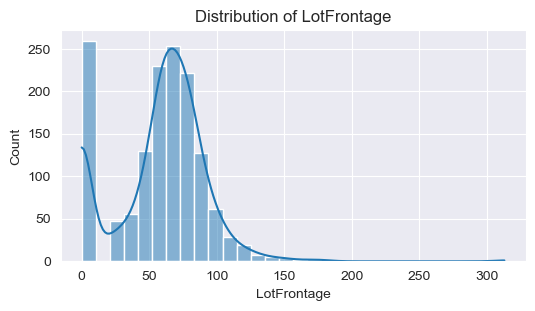

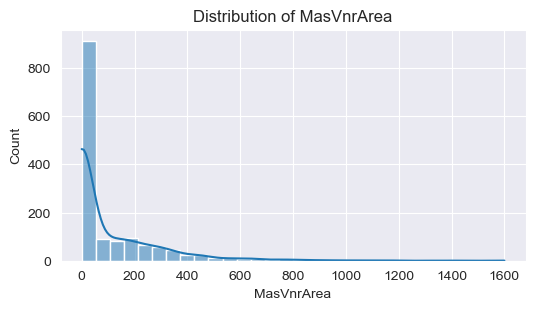

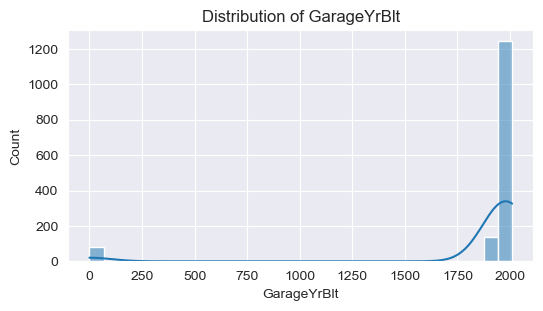

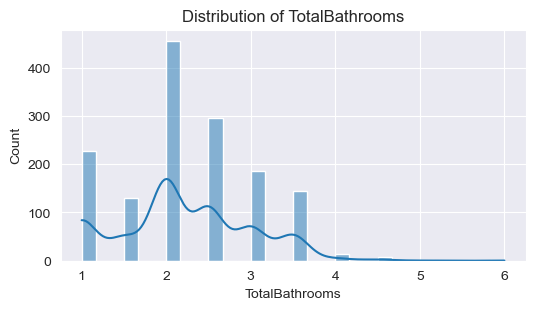

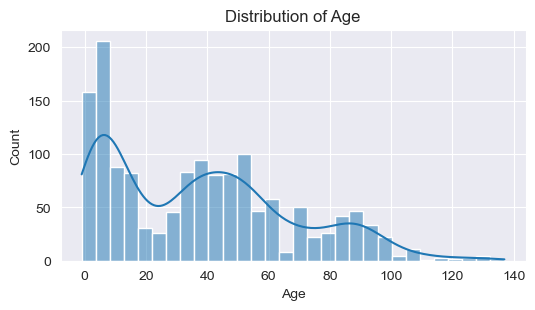

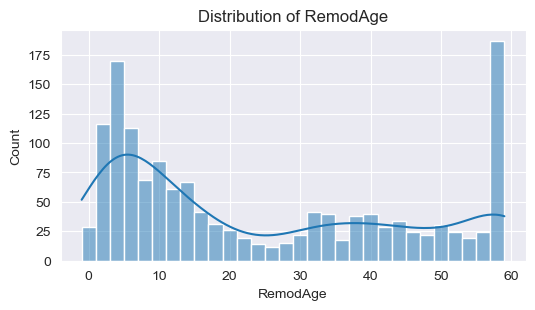

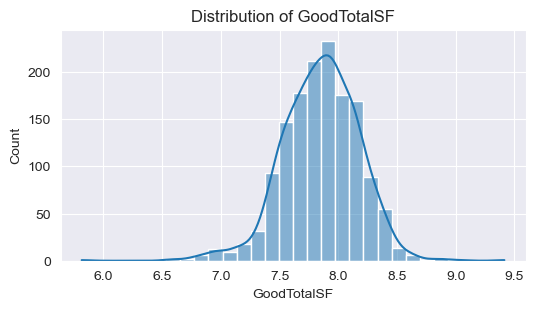

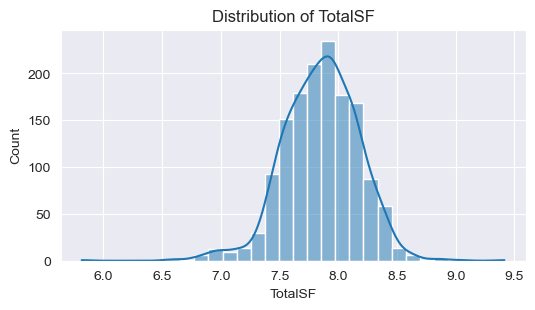

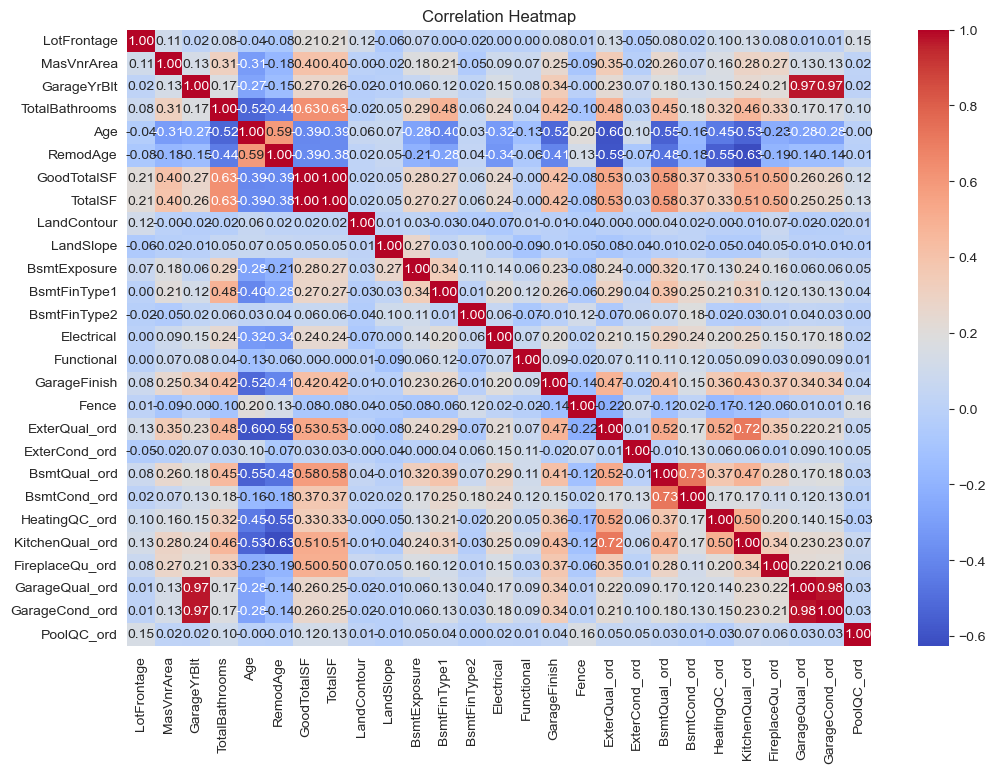

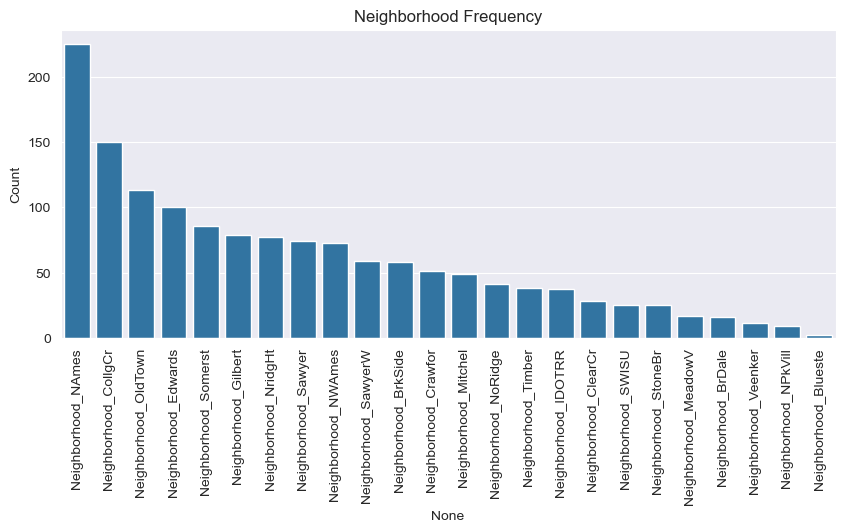

In [40]:
# Visualization: Histograms for continuous/engineered features
import matplotlib.pyplot as plt
import seaborn as sns

continuous_features = [
    'LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'TotalBathrooms', 'Age', 'RemodAge', 'GoodTotalSF', 'TotalSF'
]

for col in continuous_features:
    plt.figure(figsize=(6, 3))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

ordinal_features = [col for col in data.columns if col.endswith('_ord') or col in ['LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence', 'Electrical', 'Functional']]

corr_cols = [col for col in continuous_features + ordinal_features if col in data.columns]
plt.figure(figsize=(12, 8))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

onehot_cols = [col for col in data.columns if col.startswith('Neighborhood_')]
if onehot_cols:
    neighborhood_counts = data[onehot_cols].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=neighborhood_counts.index, y=neighborhood_counts.values)
    plt.xticks(rotation=90)
    plt.title('Neighborhood Frequency')
    plt.ylabel('Count')
    plt.show()

In [41]:
# Set 'SalePrice' as y
#y = data['SalePrice'] if 'SalePrice' in data.columns else None

# Log-transform y to make it less right skewed
y = np.log1p(data['SalePrice']) if 'SalePrice' in data.columns else None
X = data.drop(columns=['SalePrice']) if 'SalePrice' in data.columns else data.copy()

imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

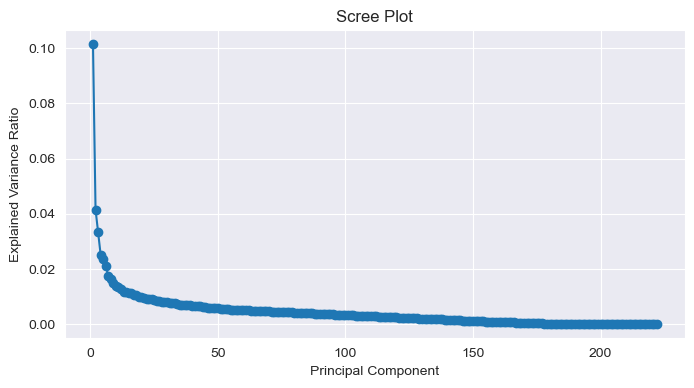

In [42]:
# PCA & Scree Plot

# Scree plot for all components
pca_full = PCA()
pca_full.fit(X_scaled)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

# PCA with 100 components
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)

In [43]:
# Train/test split
X_train_hierarchical, X_test_hierarchical, y_train_hierarchical, y_test_hierarchical = train_test_split(X_pca, y.values, test_size=0.2, random_state=1234)

X_total = X_train_hierarchical
y_total = y_train_hierarchical

X_train, X_test, y_train, y_test = train_test_split(X_total, y_total, test_size=0.2, random_state=1234)

In [44]:
torch.manual_seed(50) # this makes results reproducible

# If using a GPU, use option 1, if not, use option 2.
 # (If we using GPU, we need to place the class we defined to be put onto the GPU)

# 1
# this says " if there is a GPU, make sure my model can be used on the GPU"
# "if a GPU is not available, then use the CPU"

# 2
#model = mynetwork()

#training settings
batch_size = 100
num_epochs = 500
learning_rate = 1e-3
criterion = nn.MSELoss()

# print interval during the training
print_interval=20

# what this does is save the actual gpu device to a variable.
# in the next cell, we will use this `device` variable
# to say "make my data compatable with my model if it is on the GPU"


In [45]:
def train(training_inputs, training_outputs, network, epochs, learning_rate,
          batch_size, loss_function, print_interval):
  """
  Trains a neural network model using the specified parameters.

  Args:
      training_inputs (numpy.ndarray): Input data (features) for training.
      training_outputs (numpy.ndarray): Target outputs (labels) for training.
      network (torch.nn.Module): The neural network model to be trained.
      epochs (int): Number of training epochs.
      learning_rate (float): Learning rate for optimization.
      batch_size (int): Batch size for mini-batch gradient descent.
      loss_function (torch.nn.Module): Loss function for optimization.
      print_interval (int): Interval for printing training progress.

  Returns:
      None
  """
  train_dataset = torch.utils.data.TensorDataset(torch.from_numpy(training_inputs).float(),
                                                 torch.from_numpy(training_outputs).float())

  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                             shuffle=True)

  optimizer = torch.optim.AdamW(network.parameters(), lr=learning_rate, weight_decay=1e-4)
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)
  track_losses = np.zeros(epochs)

  start = time.time()

  # here is the main part of the training procedure.
  for epoch in range(1, epochs+1):
      for batch_idx, (X, y) in enumerate(train_loader):
          # grab the x's for this batch
          data = X

          data = data.to(DEVICE)

          # find the predictions f(x) for this batch using the forward() method
          output = network.forward(data)

          # find the loss. This calculates MSE using the pytorch version of MSE
          # ('criterion` in previous cell)
          loss = loss_function(output, y.view([-1, 1]).to(DEVICE))

          optimizer.zero_grad()

          # "calculate the gradients for the model parameters"
          loss.backward()

          # "add the gradients to the model parameters"
          optimizer.step()

      scheduler.step()
      # housekeeping - keep track of our losses and print them as we go
      training_loss = loss.item()**.5
      track_losses[epoch-1] = training_loss
      if epoch % print_interval == 0:
          print('epoch: %4d training loss:%10.3e time:%7.1f'%(epoch, training_loss, time.time()-start))

  return network, track_losses

In [46]:
def model_eva(XTrain,XTest,yTrain,yTest,model):
  """
  Evaluates a machine learning model's performance on training and test data.

  Args:
    XTrain (numpy.ndarray): Training input features.
    XTest (numpy.ndarray): Test input features.
    yTrain (numpy.ndarray): Actual training target values.
    yTest (numpy.ndarray): Actual test target values.
    model (torch.nn.Module): Trained PyTorch model.

  Returns:
    tuple: A tuple containing the following evaluation metrics:
    - MAE_train (float): Mean Absolute Error on the training set.
    - MSE_train (float): Mean Squared Error on the training set.
    - RMSE_train (float): Root Mean Squared Error on the training set.
    - R2_train (float): R-squared (coefficient of determination) on the training set.
    - MAE_test (float): Mean Absolute Error on the test set.
    - MSE_test (float): Mean Squared Error on the test set.
    - RMSE_test (float): Root Mean Squared Error on the test set.
    - R2_test (float): R-squared (coefficient of determination) on the test set.
  """
  # since we have placed our model onto the gpu, we must also ensure that the
  # inputs to the model are also compatable with the gpu, so we manually tell
  # pytorch to make a new Tensor from our numpy array, and add the .cuda() to
  # ensure that this new tensor is GPU-compatable.
  XTrain_th = torch.from_numpy(XTrain).float().to(DEVICE)
  XTest_th = torch.from_numpy(XTest).float().to(DEVICE)
  #yTrain_th=torch.Tensor(yTrain).cuda()
  #yTest_th=torch.Tensor(yTest).cuda()

  # get predictions on the training set
  yTrain_pred = model.forward(XTrain_th)

  # since we are using sklearn functions, these must be numpy arrays,
  # so we manually change them from torch.Tensors to np.ndarray's
  yTrain_pred_np = yTrain_pred.cpu().detach().numpy().reshape(-1)

  yTest_pred = model.forward(XTest_th)
  yTest_pred_np = yTest_pred.cpu().detach().numpy().reshape(-1)

  MAE_train=mean_absolute_error(yTrain_pred_np,yTrain)
  MSE_train=mean_squared_error(yTrain_pred_np,yTrain)
  RMSE_train=np.sqrt(mean_squared_error(yTrain_pred_np,yTrain))
  R2_train=r2_score(yTrain_pred_np,yTrain)

  MAE_test=mean_absolute_error(yTest_pred_np,yTest)
  MSE_test=mean_squared_error(yTest_pred_np,yTest)
  RMSE_test=np.sqrt(mean_squared_error(yTest_pred_np,yTest))
  R2_test=r2_score(yTest_pred_np,yTest)

  return MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test

In [47]:
if torch.cuda.is_available():
    print('CUDA available')
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA *not* available')


CUDA *not* available


In [48]:
X_train.shape

(934, 100)

In [49]:
# Neural Network 1 (baseline)
class mynetwork_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(100,80),
            nn.LeakyReLU(),
            nn.Linear(80,50),
            nn.LeakyReLU(),
            nn.Linear(50,1)
        )
    def forward(self, x):
        x = self.structure(x)
        return x

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_1 = mynetwork_1().to(DEVICE)

In [50]:
# Neural Network 2
class mynetwork_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(100, 80),
            nn.ReLU(),
            nn.Linear(80, 60),
            nn.ReLU(),
            nn.Linear(60, 40),
            nn.ReLU(),
            nn.Linear(40, 1)
        )
    def forward(self, x):
        x = self.structure(x)
        return x

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_2 = mynetwork_2().to(DEVICE)

In [51]:
# Neural Network 3
class mynetwork_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.structure(x)
        return x

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_3 = mynetwork_3().to(DEVICE)

In [52]:
# Training and evaluation hyperparameters
batch_size = 50
num_epochs = 1000
learning_rate = 1e-3
criterion = nn.HuberLoss()

results = []

In [53]:
# Train and evaluate NN_1
network_1, losses_1 = train(X_train, y_train, model_1, num_epochs, learning_rate, batch_size, criterion, print_interval)
MAE_train_nn1, MSE_train_nn1, RMSE_train_nn1, R2_train_nn1, MAE_test_nn1, MSE_test_nn1, RMSE_test_nn1, R2_test_nn1 = model_eva(X_train, X_test, y_train, y_test, network_1)
results.append(["NN_1", MAE_train_nn1, MSE_train_nn1, RMSE_train_nn1, R2_train_nn1, MAE_test_nn1, MSE_test_nn1, RMSE_test_nn1, R2_test_nn1])

epoch:   20 training loss: 2.817e-01 time:    0.5
epoch:   40 training loss: 3.212e-01 time:    1.1
epoch:   60 training loss: 6.651e-02 time:    1.6
epoch:   80 training loss: 8.999e-02 time:    2.3
epoch:  100 training loss: 5.870e-02 time:    2.9
epoch:  120 training loss: 1.462e-01 time:    3.5
epoch:  140 training loss: 2.141e-01 time:    4.0
epoch:  160 training loss: 5.979e-02 time:    4.5
epoch:  180 training loss: 7.128e-02 time:    5.0
epoch:  200 training loss: 6.156e-02 time:    5.4
epoch:  220 training loss: 8.699e-02 time:    6.0
epoch:  240 training loss: 2.152e-01 time:    6.5
epoch:  260 training loss: 6.449e-02 time:    7.3
epoch:  280 training loss: 7.663e-02 time:    7.8
epoch:  300 training loss: 2.893e-01 time:    8.6
epoch:  320 training loss: 6.203e-03 time:    9.1
epoch:  340 training loss: 8.088e-03 time:    9.6
epoch:  360 training loss: 1.512e-02 time:   10.1
epoch:  380 training loss: 1.263e-01 time:   10.7
epoch:  400 training loss: 4.591e-02 time:   11.2


In [54]:
# Train and evaluate NN_2
network_2, losses_2 = train(X_train, y_train, model_2, num_epochs, learning_rate, batch_size, criterion, print_interval)
MAE_train_nn2, MSE_train_nn2, RMSE_train_nn2, R2_train_nn2, MAE_test_nn2, MSE_test_nn2, RMSE_test_nn2, R2_test_nn2 = model_eva(X_train, X_test, y_train, y_test, network_2)
results.append(["NN_2", MAE_train_nn2, MSE_train_nn2, RMSE_train_nn2, R2_train_nn2, MAE_test_nn2, MSE_test_nn2, RMSE_test_nn2, R2_test_nn2])

epoch:   20 training loss: 1.899e-01 time:    0.6
epoch:   40 training loss: 1.543e-01 time:    1.5
epoch:   60 training loss: 1.054e-01 time:    2.3
epoch:   80 training loss: 7.223e-02 time:    3.0
epoch:  100 training loss: 1.962e-01 time:    3.6
epoch:  120 training loss: 1.435e-01 time:    4.2
epoch:  140 training loss: 1.124e-01 time:    4.8
epoch:  160 training loss: 1.275e-01 time:    5.5
epoch:  180 training loss: 9.166e-02 time:    6.2
epoch:  200 training loss: 5.158e-02 time:    7.0
epoch:  220 training loss: 8.710e-02 time:    7.8
epoch:  240 training loss: 8.729e-02 time:    8.6
epoch:  260 training loss: 6.349e-02 time:    9.4
epoch:  280 training loss: 1.893e-01 time:   10.3
epoch:  300 training loss: 8.803e-02 time:   11.0
epoch:  320 training loss: 1.330e-02 time:   12.0
epoch:  340 training loss: 9.406e-03 time:   12.7
epoch:  360 training loss: 1.347e-02 time:   13.5
epoch:  380 training loss: 3.492e-02 time:   14.2
epoch:  400 training loss: 3.430e-02 time:   14.8


In [55]:
# Train and evaluate NN_3
network_3, losses_3 = train(X_train, y_train, model_3, num_epochs, learning_rate, batch_size, criterion, print_interval)
MAE_train_nn3, MSE_train_nn3, RMSE_train_nn3, R2_train_nn3, MAE_test_nn3, MSE_test_nn3, RMSE_test_nn3, R2_test_nn3 = model_eva(X_train, X_test, y_train, y_test, network_3)
results.append(["NN_3", MAE_train_nn3, MSE_train_nn3, RMSE_train_nn3, R2_train_nn3, MAE_test_nn3, MSE_test_nn3, RMSE_test_nn3, R2_test_nn3])

epoch:   20 training loss: 6.101e-01 time:    0.9
epoch:   40 training loss: 4.731e-01 time:    1.6
epoch:   60 training loss: 4.233e-01 time:    2.6
epoch:   80 training loss: 3.235e-01 time:    3.6
epoch:  100 training loss: 3.979e-01 time:    4.5
epoch:  120 training loss: 3.875e-01 time:    5.4
epoch:  140 training loss: 3.365e-01 time:    6.2
epoch:  160 training loss: 3.271e-01 time:    7.0
epoch:  180 training loss: 3.841e-01 time:    7.8
epoch:  200 training loss: 2.640e-01 time:    8.9
epoch:  220 training loss: 2.368e-01 time:    9.7
epoch:  240 training loss: 2.276e-01 time:   10.5
epoch:  260 training loss: 2.107e-01 time:   11.5
epoch:  280 training loss: 2.860e-01 time:   12.4
epoch:  300 training loss: 2.018e-01 time:   13.3
epoch:  320 training loss: 1.796e-01 time:   14.0
epoch:  340 training loss: 1.516e-01 time:   14.8
epoch:  360 training loss: 1.425e-01 time:   15.6
epoch:  380 training loss: 1.103e-01 time:   16.4
epoch:  400 training loss: 8.333e-02 time:   17.2


In [56]:
# Neural Network 4
class mynetwork_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(100, 256),
            nn.BatchNorm1d(256),
            nn.ELU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.structure(x)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_4 = mynetwork_4().to(DEVICE)

In [57]:
# Neural Network 5
class mynetwork_5(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(100, 512),
            nn.SELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.SELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.SELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.SELU(),
            nn.Linear(64, 1)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='linear')
    def forward(self, x):
        return self.structure(x)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_5 = mynetwork_5().to(DEVICE)

In [58]:
network_4, losses_4 = train(X_train, y_train, model_4, num_epochs, learning_rate, batch_size, criterion, print_interval)
MAE_train_nn4, MSE_train_nn4, RMSE_train_nn4, R2_train_nn4, MAE_test_nn4, MSE_test_nn4, RMSE_test_nn4, R2_test_nn4 = model_eva(X_train, X_test, y_train, y_test, network_4)
results.append(["NN_4", MAE_train_nn4, MSE_train_nn4, RMSE_train_nn4, R2_train_nn4, MAE_test_nn4, MSE_test_nn4, RMSE_test_nn4, R2_test_nn4])

epoch:   20 training loss: 3.571e-01 time:    8.6
epoch:   40 training loss: 3.503e-01 time:    9.8
epoch:   60 training loss: 1.494e-01 time:   10.9
epoch:   80 training loss: 1.044e-01 time:   11.9
epoch:  100 training loss: 1.409e-01 time:   13.0
epoch:  120 training loss: 1.087e-01 time:   14.1
epoch:  140 training loss: 1.469e-01 time:   15.2
epoch:  160 training loss: 1.903e-01 time:   16.3
epoch:  180 training loss: 1.408e-01 time:   17.3
epoch:  200 training loss: 1.444e-01 time:   21.3
epoch:  220 training loss: 6.806e-02 time:   22.5
epoch:  240 training loss: 1.227e-01 time:   23.6
epoch:  260 training loss: 1.063e-01 time:   24.6
epoch:  280 training loss: 1.176e-01 time:   25.6
epoch:  300 training loss: 7.195e-02 time:   26.7
epoch:  320 training loss: 1.251e-01 time:   27.8
epoch:  340 training loss: 6.018e-02 time:   28.8
epoch:  360 training loss: 6.141e-02 time:   29.8
epoch:  380 training loss: 6.432e-02 time:   31.3
epoch:  400 training loss: 6.097e-02 time:   33.9


In [59]:
network_5, losses_5 = train(X_train, y_train, model_5, num_epochs, learning_rate, batch_size, criterion, print_interval)
MAE_train_nn5, MSE_train_nn5, RMSE_train_nn5, R2_train_nn5, MAE_test_nn5, MSE_test_nn5, RMSE_test_nn5, R2_test_nn5 = model_eva(X_train, X_test, y_train, y_test, network_5)
results.append(["NN_5", MAE_train_nn5, MSE_train_nn5, RMSE_train_nn5, R2_train_nn5, MAE_test_nn5, MSE_test_nn5, RMSE_test_nn5, R2_test_nn5])

epoch:   20 training loss: 3.122e-01 time:    1.2
epoch:   40 training loss: 1.774e-01 time:    2.5
epoch:   60 training loss: 1.287e-01 time:    4.0
epoch:   80 training loss: 9.975e-02 time:    5.3
epoch:  100 training loss: 9.558e-02 time:    6.7
epoch:  120 training loss: 9.637e-02 time:    8.2
epoch:  140 training loss: 7.471e-02 time:    9.4
epoch:  160 training loss: 1.580e-01 time:   10.7
epoch:  180 training loss: 1.405e-01 time:   12.2
epoch:  200 training loss: 1.208e-01 time:   13.5
epoch:  220 training loss: 9.804e-02 time:   14.7
epoch:  240 training loss: 8.604e-02 time:   16.1
epoch:  260 training loss: 8.343e-02 time:   17.4
epoch:  280 training loss: 7.307e-02 time:   18.6
epoch:  300 training loss: 6.768e-02 time:   20.1
epoch:  320 training loss: 7.034e-02 time:   21.3
epoch:  340 training loss: 1.257e-01 time:   22.5
epoch:  360 training loss: 9.436e-02 time:   24.0
epoch:  380 training loss: 1.001e-01 time:   25.3
epoch:  400 training loss: 5.161e-02 time:   26.6


In [60]:
print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"], tablefmt="grid"))

+---------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| Model   |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |   Test MSE |   Test RMSE |   Test R^2 |
+=========+================+================+=================+================+============+============+=============+============+
| NN_1    |      0.0129106 |    0.000531886 |       0.0230627 |       0.996538 |  0.579859  |  0.719423  |    0.848188 |   0.216416 |
+---------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| NN_2    |      0.0125694 |    0.000457259 |       0.0213836 |       0.997055 |  0.533515  |  0.797515  |    0.893037 |   0.230749 |
+---------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| NN_3    |      0.0374265 |    0.00257014  |       0.0506966 

In [61]:
print(torch.version.cuda)

None
